# STATISTICAL ANALYSIS

In [2]:
import pandas as pd
df = pd.read_csv("../data/cleaned_superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2024-10001,2024-11-23,2024-11-24,Standard Class,CUST-1001,Customer 1,Consumer,United States,San Diego,...,22280,West,PROD-2001,Furniture,Chairs,Chairs Product 1,714.90,2,0.0,103.84
1,2,CA-2024-10002,2024-04-29,2024-05-04,First Class,CUST-1002,Customer 2,Consumer,United States,Seattle,...,30926,South,PROD-2002,Technology,Phones,Phones Product 2,3585.78,9,0.3,-142.64
2,3,CA-2024-10003,2024-06-23,2024-06-26,First Class,CUST-1003,Customer 3,Consumer,United States,Houston,...,70217,East,PROD-2003,Office Supplies,Binders,Binders Product 3,481.87,2,0.2,131.91
3,4,CA-2024-10004,2024-07-12,2024-07-13,Standard Class,CUST-1004,Customer 4,Home Office,United States,Tacoma,...,39871,Central,PROD-2004,Technology,Copiers,Copiers Product 4,4429.55,6,0.1,896.04
4,5,CA-2024-10005,2024-02-10,2024-02-17,Second Class,CUST-1005,Customer 5,Home Office,United States,Houston,...,44993,East,PROD-2005,Office Supplies,Paper,Paper Product 5,2277.98,6,0.1,79.94


In [3]:
df["Sales"].dtype

dtype('float64')

DESCRIPTIVE STATISTICS USING MEAN,MEDIAN,MODE,STD DEV,SKEWNESS

In [4]:
# Mean
print("Mean:", df["Sales"].mean())

# Median
print("Median:", df["Sales"].median())

# Mode
print("Mode:", df["Sales"].mode())

# Standard Deviation
print("Standard Deviation:", df["Sales"].std())

# Skewness
print("Skewness:", df["Sales"].skew())

Mean: 2585.80285
Median: 2603.54
Mode: 0    2546.43
Name: Sales, dtype: float64
Standard Deviation: 1430.9945084077265
Skewness: -0.06445764597642403


In [5]:
# Mean
print("Mean:", df["Profit"].mean())

# Median
print("Median:", df["Profit"].median())

# Mode
print("Mode:", df["Profit"].mode())

# Standard Deviation
print("Standard Deviation:", df["Profit"].std())

# Skewness
print("Skewness:", df["Profit"].skew())

Mean: 259.65281
Median: 153.745
Mode: 0   -235.56
Name: Profit, dtype: float64
Standard Deviation: 457.2011691917619
Skewness: 0.7481670234497547


In [6]:
# Mean
print("Mean:", df["Quantity"].mean())

# Median
print("Median:", df["Quantity"].median())

# Mode
print("Mode:", df["Quantity"].mode())

# Standard Deviation
print("Standard Deviation:", df["Quantity"].std())

# Skewness
print("Skewness:", df["Quantity"].skew())

Mean: 5.44
Median: 5.0
Mode: 0    6
Name: Quantity, dtype: int64
Standard Deviation: 2.8050433629924996
Skewness: 0.041676980152379264


In [7]:
# Mean
print("Mean:", df["Discount"].mean())

# Median
print("Median:", df["Discount"].median())

# Mode
print("Mode:", df["Discount"].mode())

# Standard Deviation
print("Standard Deviation:", df["Discount"].std())

# Skewness
print("Skewness:", df["Discount"].skew())

Mean: 0.152
Median: 0.2
Mode: 0    0.3
Name: Discount, dtype: float64
Standard Deviation: 0.11299897684832748
Skewness: -0.0184521427456993


HYPOTHESIS TESTING USING SCIPY.STATS:

T-TEST COMPARING TWO GROUPS

In [8]:
from scipy.stats import ttest_ind

# Select Sales data for two regions
east_sales = df.loc[df["Region"] == "East", "Sales"]
west_sales = df.loc[df["Region"] == "West", "Sales"]

# Perform Independent T-Test
t_stat, p_value = ttest_ind(east_sales, west_sales)

# Display results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in Sales between East and West regions.")
else:
    print("There is no statistically significant difference in Sales between East and West regions.")

T-Statistic: 0.20312748107663975
P-Value: 0.8391195424325617
There is no statistically significant difference in Sales between East and West regions.


In [9]:
from scipy.stats import ttest_ind

# Select Profit data for two regions
east_profit = df.loc[df["Region"] == "East", "Profit"]
west_profit = df.loc[df["Region"] == "West", "Profit"]

# Perform Independent T-Test
t_stat, p_value = ttest_ind(east_profit, west_profit)

# Display results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in Profit between East and West regions.")
else:
    print("There is no statistically significant difference in Profit between East and West regions.")

T-Statistic: -1.1457906635605783
P-Value: 0.2524399066562321
There is no statistically significant difference in Profit between East and West regions.


CHI - SQUARE TEST ( CATEGORICAL RELATIONSHIPS )

In [10]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df["Category"], df["Ship Mode"])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Display results
print("\nChi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

# Interpretation
if p_value < 0.05:
    print("There is a significant relationship between Category and Ship Mode.")
else:
    print("There is no significant relationship between Category and Ship Mode.")

Contingency Table:
Ship Mode        First Class  Same Day  Second Class  Standard Class
Category                                                            
Furniture                 79        86            79              75
Office Supplies           76        86            81              62
Technology                92        94            88             102

Chi-Square Statistic: 4.647144412506942
P-Value: 0.5897976560164027
Degrees of Freedom: 6
There is no significant relationship between Category and Ship Mode.


CONFIDENCE INTERVALS

In [11]:
import numpy as np
from scipy import stats

# Sales data
sales = df["Sales"].dropna()

# Sample statistics
mean = np.mean(sales)
sem = stats.sem(sales)  # Standard Error of the Mean

# 95% Confidence Interval
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales)-1,
    loc=mean,
    scale=sem
)

print("Mean Sales:", mean)
print("95% Confidence Interval:", confidence_interval)

Mean Sales: 2585.80285
95% Confidence Interval: (np.float64(2497.0029356258383), np.float64(2674.602764374162))


# TIME SERIES ANALYSIS

CONVERT TO TIME SERIES

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [13]:
df = df.set_index("Order Date")

In [14]:
monthly_sales = df["Sales"].resample("ME").sum()

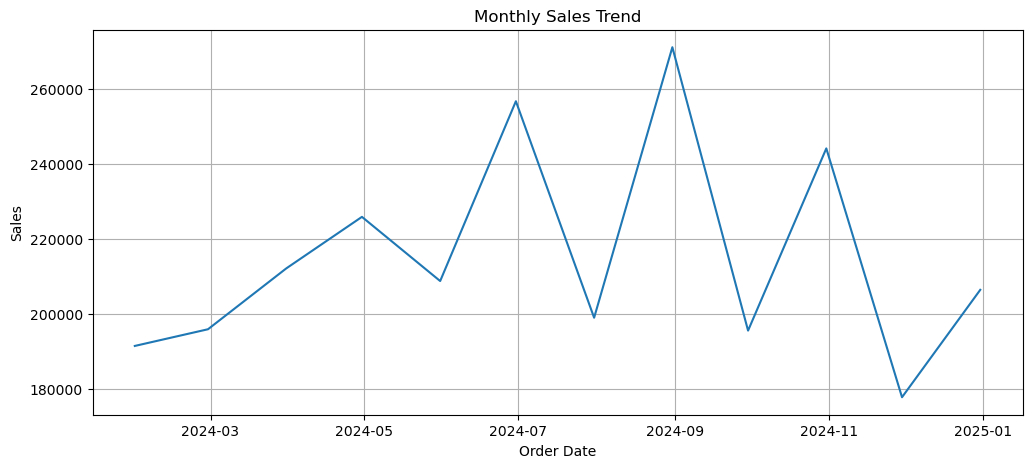

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

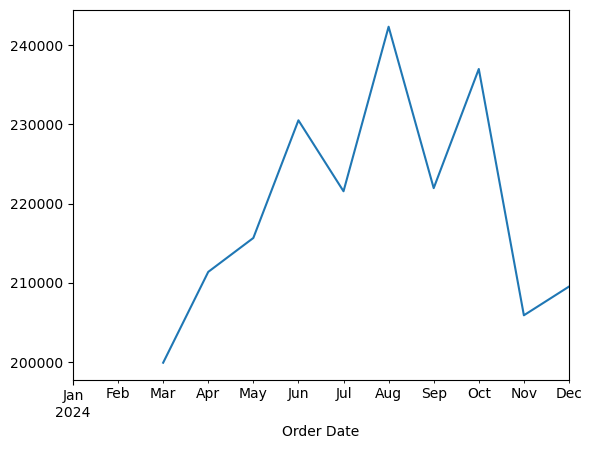

In [19]:
monthly_sales.rolling(3).mean().plot()
plt.show()

In [20]:
print(df.columns)
print(df.index)

Index(['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
DatetimeIndex(['2024-11-23', '2024-04-29', '2024-06-23', '2024-07-12',
               '2024-02-10', '2024-11-07', '2024-07-24', '2024-05-06',
               '2024-01-25', '2024-12-14',
               ...
               '2024-09-20', '2024-06-12', '2024-04-09', '2024-06-14',
               '2024-05-17', '2024-10-15', '2024-12-04', '2024-05-20',
               '2024-05-07', '2024-03-09'],
              dtype='datetime64[ns]', name='Order Date', length=1000, freq=None)


NOW WE ARE RESAMPLING DATA (DAILY,WEEKLY,MONTHLY)

In [21]:
daily_sales = df["Sales"].resample("D").sum()

print(daily_sales.head())

Order Date
2024-01-01     4446.53
2024-01-02     3009.07
2024-01-03    14097.80
2024-01-04    16498.31
2024-01-05    11714.06
Freq: D, Name: Sales, dtype: float64


In [51]:
daily_profit = df["Profit"].resample("D").sum()

print(daily_profit.head())

Order Date
2024-01-01     444.91
2024-01-02    -412.64
2024-01-03     449.51
2024-01-04    2913.03
2024-01-05    1266.33
Freq: D, Name: Profit, dtype: float64


In [22]:
weekly_sales = df["Sales"].resample("W").sum()

print(weekly_sales.head())

Order Date
2024-01-07    63845.92
2024-01-14    35681.30
2024-01-21    32937.04
2024-01-28    47979.27
2024-02-04    47037.50
Freq: W-SUN, Name: Sales, dtype: float64


In [52]:
weekly_profit = df["Profit"].resample("W").sum()

print(weekly_profit.head())

Order Date
2024-01-07    6610.17
2024-01-14    4235.04
2024-01-21    5625.27
2024-01-28    4070.43
2024-02-04    3637.96
Freq: W-SUN, Name: Profit, dtype: float64


In [23]:
monthly_sales = df["Sales"].resample("ME").sum()

print(monthly_sales.head())

Order Date
2024-01-31    191543.40
2024-02-29    195993.48
2024-03-31    212208.07
2024-04-30    225956.35
2024-05-31    208845.66
Freq: ME, Name: Sales, dtype: float64


In [53]:
monthly_profit = df["Profit"].resample("ME").sum()

print(monthly_profit.head())

Order Date
2024-01-31    22330.57
2024-02-29    17211.68
2024-03-31    20287.75
2024-04-30    23285.36
2024-05-31    19747.65
Freq: ME, Name: Profit, dtype: float64


In [24]:
monthly_sales = df["Sales"].resample("ME").sum()

In [25]:
print("Daily Sales:")
print(daily_sales.head())

print("\nWeekly Sales:")
print(weekly_sales.head())

print("\nMonthly Sales:")
print(monthly_sales.head())

Daily Sales:
Order Date
2024-01-01     4446.53
2024-01-02     3009.07
2024-01-03    14097.80
2024-01-04    16498.31
2024-01-05    11714.06
Freq: D, Name: Sales, dtype: float64

Weekly Sales:
Order Date
2024-01-07    63845.92
2024-01-14    35681.30
2024-01-21    32937.04
2024-01-28    47979.27
2024-02-04    47037.50
Freq: W-SUN, Name: Sales, dtype: float64

Monthly Sales:
Order Date
2024-01-31    191543.40
2024-02-29    195993.48
2024-03-31    212208.07
2024-04-30    225956.35
2024-05-31    208845.66
Freq: ME, Name: Sales, dtype: float64


NOW WE ARE DECOMPOSING INTO TREND,SEASONALITY,RESIDUALS

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [27]:
monthly_sales = df["Sales"].resample("ME").sum()

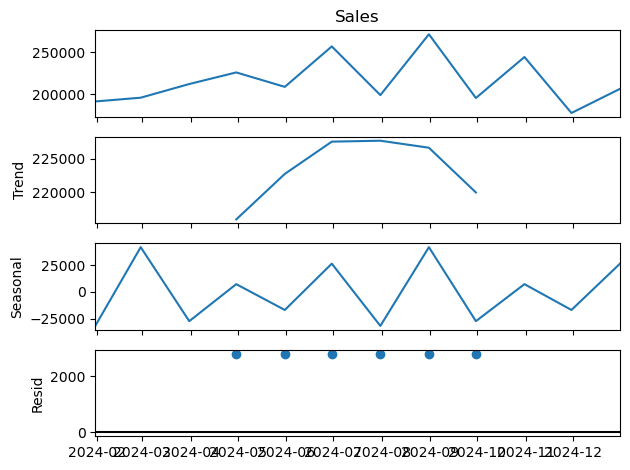

In [28]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=6
)

decomposition.plot()
plt.show()

NOW WE ARE BUILDING SIMPLE MOVING AVERAGE FORECAST

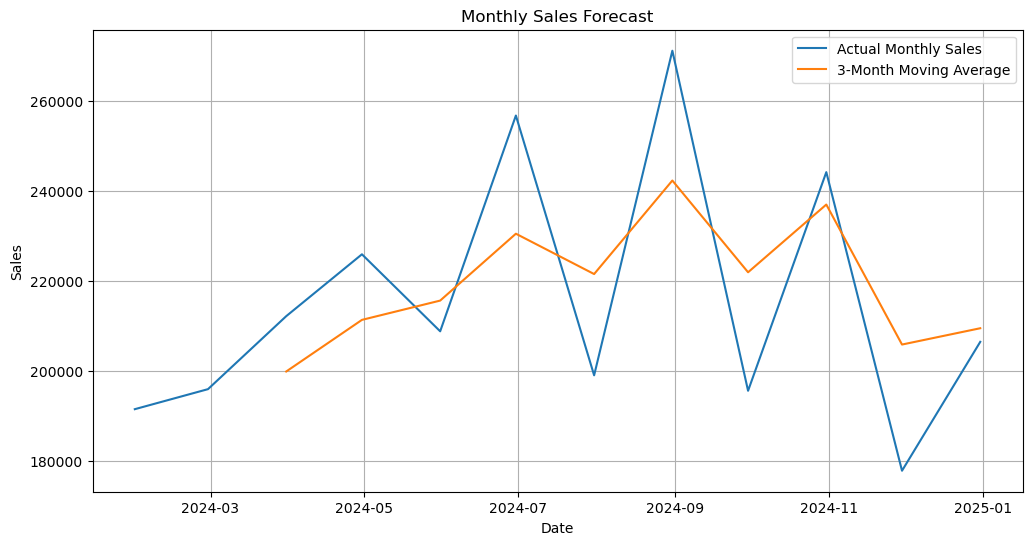

In [29]:
moving_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Actual Monthly Sales")
plt.plot(moving_avg, label="3-Month Moving Average")
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# CUSTOMER SEGMENTATION (CLUSTERING)

NOW PREPARE FEATURES FOR CLUSTERING (SCALE USING STANDARDSCALER)

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [31]:
X = df[["Sales", "Profit"]].dropna()

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.30806861 -0.34096758]
 [ 0.6991484  -0.88034357]
 [-1.47099489 -0.27954156]
 [ 1.28908232  1.39261591]
 [-0.21521877 -0.39326832]]


In [33]:
import warnings
warnings.filterwarnings("ignore")

In [34]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

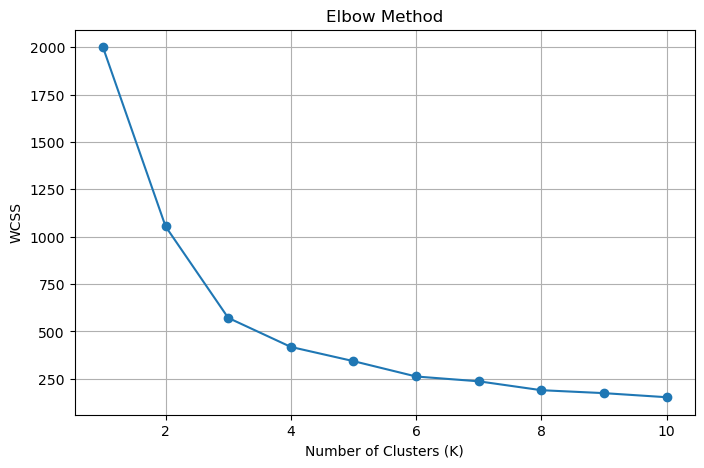

In [35]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

# Select multiple numeric features
X = df[["Sales", "Profit", "Quantity", "Discount"]].dropna()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first 5 scaled values
print(X_scaled[:5])

[[-1.30806861 -0.34096758 -1.22697614 -1.345818  ]
 [ 0.6991484  -0.88034357  1.26977764  1.31040174]
 [-1.47099489 -0.27954156 -1.22697614  0.42499516]
 [ 1.28908232  1.39261591  0.1997403  -0.46041142]
 [-0.21521877 -0.39326832  0.1997403  -0.46041142]]


APPLY K MEANS CLUSTERING

In [37]:
from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df["Cluster"] = clusters

# Display first 5 rows
print(df[["Sales", "Profit", "Cluster"]].head())

              Sales  Profit  Cluster
Order Date                          
2024-11-23   714.90  103.84        2
2024-04-29  3585.78 -142.64        3
2024-06-23   481.87  131.91        1
2024-07-12  4429.55  896.04        0
2024-02-10  2277.98   79.94        2


AND NOW WE ARE FINDING OPTIMAL K USING ELBOW METHOD

In [38]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

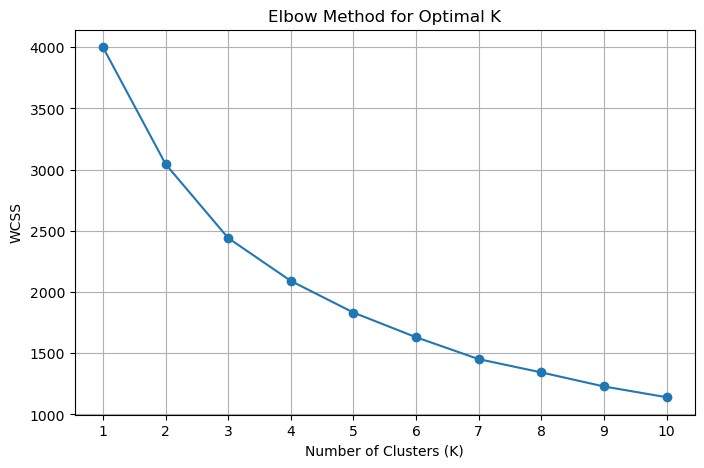

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

AND NOW VISUALIZE CLUSTERS USING PCA (2D PLOT )

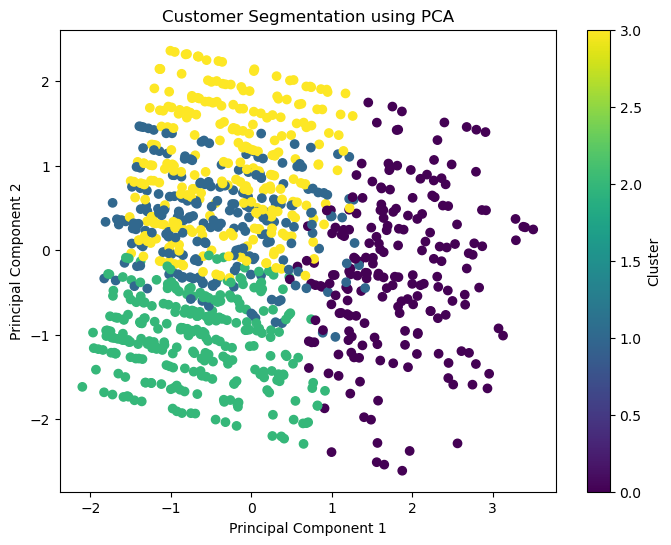

In [40]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clusters,
            cmap='viridis')

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

AND NOW PROFILE EACH SEGMENT WITH RECOMMENDATIONS

Cluster 0 → High-value customers.
    
Cluster 1 → Low-profit customers.
    
Cluster 2 → Moderate buyers.
    
Cluster 3 → Premium custom

# BASIC PREDICTIVE MODEL

DEFINE TARGET AND FEATURES VARIABLE 

In [44]:
# Add cluster labels to the original data
df["Cluster"] = clusters

In [45]:
# Profile each cluster
cluster_profile = df.groupby("Cluster")[["Sales", "Profit", "Quantity", "Discount"]].mean()

print(cluster_profile)

               Sales      Profit  Quantity  Discount
Cluster                                             
0        4031.278835  947.262573  6.262136  0.150971
1        2430.294435   81.018000  3.526087  0.257391
2        2271.335704   86.273451  3.510563  0.042958
3        1969.044107   76.360429  8.364286  0.176786


In [46]:
# Features (Independent Variables)
X = df[["Quantity", "Discount", "Profit"]]

# Target Variable (Dependent Variable)
y = df["Sales"]

# Display the first few rows
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
            Quantity  Discount  Profit
Order Date                            
2024-11-23         2       0.0  103.84
2024-04-29         9       0.3 -142.64
2024-06-23         2       0.2  131.91
2024-07-12         6       0.1  896.04
2024-02-10         6       0.1   79.94

Target:
Order Date
2024-11-23     714.90
2024-04-29    3585.78
2024-06-23     481.87
2024-07-12    4429.55
2024-02-10    2277.98
Name: Sales, dtype: float64


AND NOW SPLIT DATA INTO TRAIN/TEST

In [47]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the datasets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 3)
X_test: (200, 3)
y_train: (800,)
y_test: (200,)


AND NOW BUILD LINEAR REGRESSION

In [48]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print(y_pred[:10])

import pandas as pd

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(comparison.head(10))

[2578.72269947 3138.79719407 2835.17609121 2776.61818236 2261.85040244
 2851.10822208 2198.55306479 3176.65991439 2162.47697609 2180.51075254]
   Actual Sales  Predicted Sales
0       1065.01      2578.722699
1       3809.28      3138.797194
2       2406.39      2835.176091
3       4696.99      2776.618182
4        457.22      2261.850402
5       4011.23      2851.108222
6        658.67      2198.553065
7       3704.48      3176.659914
8        522.55      2162.476976
9        859.81      2180.510753


AND HERE WE SHOULD EVALUATE MODEL : R SQUARE , MAE , RMSE

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

R² Score: 0.04351660726306994
Mean Absolute Error (MAE): 1091.6414958620333
Mean Squared Error (MSE): 1798441.3623893599
Root Mean Squared Error (RMSE): 1341.0597907585477


AND HERE IDENTIFY TOP 3 IMPORTANT FEATURES

In [50]:
import pandas as pd

# Create a DataFrame of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Calculate absolute coefficient values
feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(feature_importance)

# Display the Top 3 Important Features
print("\nTop 3 Important Features:")
print(feature_importance.head(3))

    Feature  Coefficient  Absolute Coefficient
1  Discount   657.778685            657.778685
0  Quantity     3.649586              3.649586
2    Profit     1.122867              1.122867

Top 3 Important Features:
    Feature  Coefficient  Absolute Coefficient
1  Discount   657.778685            657.778685
0  Quantity     3.649586              3.649586
2    Profit     1.122867              1.122867
